In [39]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# load model
model = joblib.load('/kaggle/input/datasets/muhammadzackyrachim/model-ramdom-forest/model_dropout_mahasiswa.pkl')

# load data
train_df = pd.read_csv('/kaggle/input/datasets/muhammadzackyrachim/modelin/train.csv')
test_df = pd.read_csv('/kaggle/input/datasets/muhammadzackyrachim/modelin/test.csv')

,feature,importance
30,Curricular units 2nd sem (approved),0.185430
31,Curricular units 2nd sem (grade),0.147599
24,Curricular units 1st sem (approved),0.115506
16,Tuition fees up to date,0.070595
25,Curricular units 1st sem (grade),0.063705
19,Age at enrollment,0.042944
29,Curricular units 2nd sem (evaluations),0.033470
3,Course,0.025703
23,Curricular units 1st sem (evaluations),0.025452
12,Admission grade,0.024955


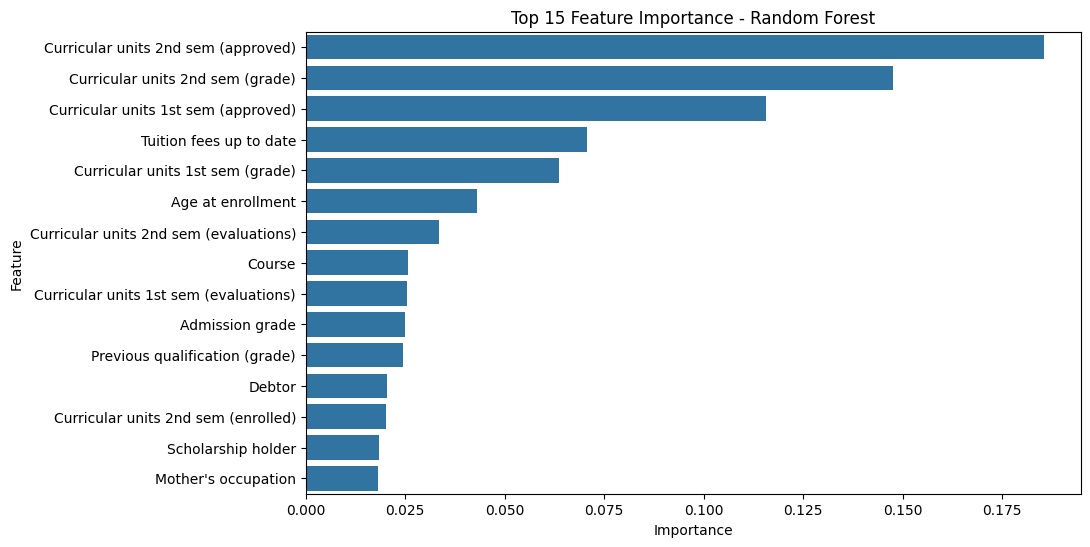

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ambil feature training (tanpa target)
X_train = train_df.drop(columns=['Target', 'dropout_risk'])

# ambil model RandomForest dari dalam pipeline
rf_model = model.named_steps['model']

# ambil feature importance
importances = rf_model.feature_importances_

# buat dataframe importance
feat_imp = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importances
}).sort_values(by='importance', ascending=False)

# tampilkan top feature
display(feat_imp.head(15))

# plot
plt.figure(figsize=(10,6))
sns.barplot(data=feat_imp.head(15), x='importance', y='feature')
plt.title('Top 15 Feature Importance - Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [41]:
target_col = 'dropout_risk'
drop_cols = ['Target', 'dropout_risk']

X_test = test_df.drop(columns=drop_cols)
y_test = test_df[target_col]

X_train = train_df.drop(columns=drop_cols)

In [42]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [43]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("=== Evaluation Metrics ===")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

=== Evaluation Metrics ===
Accuracy : 0.8791
Precision: 0.8365
Recall   : 0.7746
F1-score : 0.8044
ROC-AUC  : 0.9290


In [44]:
from sklearn.metrics import classification_report

print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['Non-Dropout', 'Dropout']))

=== Classification Report ===
              precision    recall  f1-score   support

 Non-Dropout       0.90      0.93      0.91       601
     Dropout       0.84      0.77      0.80       284

    accuracy                           0.88       885
   macro avg       0.87      0.85      0.86       885
weighted avg       0.88      0.88      0.88       885



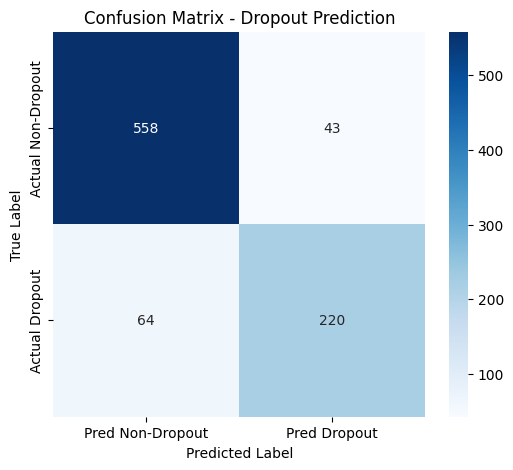

In [45]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred Non-Dropout', 'Pred Dropout'],
            yticklabels=['Actual Non-Dropout', 'Actual Dropout'])
plt.title('Confusion Matrix - Dropout Prediction')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

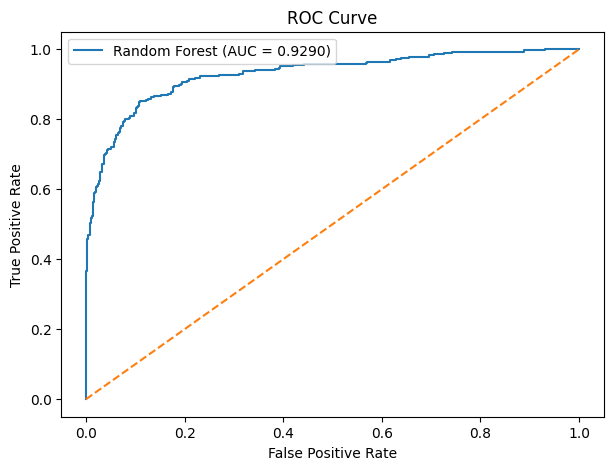

In [46]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

Jumlah fitur X_train: 36
Jumlah importance   : 36


,feature,importance
30,Curricular units 2nd sem (approved),0.185430
31,Curricular units 2nd sem (grade),0.147599
24,Curricular units 1st sem (approved),0.115506
16,Tuition fees up to date,0.070595
25,Curricular units 1st sem (grade),0.063705
19,Age at enrollment,0.042944
29,Curricular units 2nd sem (evaluations),0.033470
3,Course,0.025703
23,Curricular units 1st sem (evaluations),0.025452
12,Admission grade,0.024955


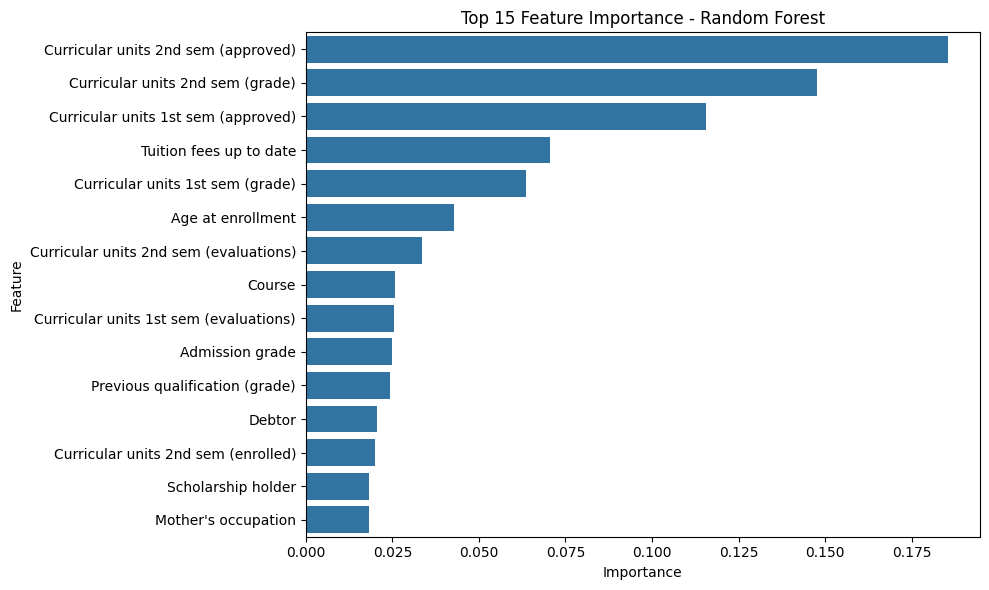

In [47]:
# =========================
# Feature Importance
# =========================
rf_model = model.named_steps['model']
importances = rf_model.feature_importances_

print("Jumlah fitur X_train:", len(X_train.columns))
print("Jumlah importance   :", len(importances))

feat_imp = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importances
}).sort_values(by='importance', ascending=False)

display(feat_imp.head(15))

plt.figure(figsize=(10,6))
sns.barplot(data=feat_imp.head(15), x='importance', y='feature')
plt.title('Top 15 Feature Importance - Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [48]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC'],
    'Score': [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_prob)
    ]
})

display(metrics_df)

,Metric,Score
0,Accuracy,0.879096
1,Precision,0.836502
2,Recall,0.774648
3,F1-score,0.804388
4,ROC-AUC,0.929027


In [49]:
feat_imp.to_csv('/kaggle/working/feature_importance.csv', index=False)
print("feature_importance.csv berhasil disimpan")

feature_importance.csv berhasil disimpan
